# Google Maps Business Analysis — Jharkhand
### Find. Analyze. Recommend. — Identifying Digital-Growth Opportunities for Local Businesses

**Objective:** Analyze 1,650 local businesses (POI data) collected from Google Maps across Jharkhand to identify businesses that do **not** have a website, and recommend real, data-backed opportunities for digital growth.

**Sections**
1. Data Collection & Overview
2. Data Cleaning
3. Exploratory Data Analysis
4. Category-wise Analysis
5. City / Location-wise Analysis
6. Opportunity Finding (High Rating + No Website)
7. Amenity Analysis (Parking & Delivery)
8. Top 10 Business Opportunities
9. Dashboard Summary
10. Final Recommendations


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')

# Brand palette
C_PRIMARY, C_SECOND, C_MINT = '#028090', '#00A896', '#02C39A'
C_ACCENT, C_DARK, C_RED = '#F0A202', '#0B2545', '#D64550'

pd.set_option('display.max_columns', None)


## 1. Data Collection & Overview

The dataset was collected from **Google Maps** (Business Name, Category, City, Locality, Address, Coordinates, Website, Phone, Rating, Opening Hours, Parking, Delivery, and Status) for Points of Interest across Jharkhand.

In [4]:
df = pd.read_excel('../data/raw/jharkhand_new_1650.xlsx')
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Shape: 1650 rows x 14 columns


,Business_Name,Category,City,Locality,Address,Latitude,Longitude,Website,Phone,Rating,Opening_Hours,Parking,Delivery,Status
0,Bokaro College 1,College,Bokaro,Main Road,"Main Road, Bokaro, Jharkhand",24.174651,84.179567,https://www.bokarocollege1.com,+91-9249827706,4.6,7AM-9PM,Limited,No,Open
1,Dhanbad Restaurant 2,Restaurant,Dhanbad,Market Area,"Market Area, Dhanbad, Jharkhand",22.647983,85.608075,https://www.dhanbadrestaurant2.com,+91-9702632297,3.8,9AM-8PM,Yes,No,Open
2,Ranchi Jewelry 3,Jewelry,Ranchi,Upper Bazar,"Upper Bazar, Ranchi, Jharkhand",24.367458,85.992558,https://www.ranchijewelry3.com,+91-9465341213,3.9,7AM-9PM,Yes,No,Open
3,Khunti Mobile Store 4,Mobile Store,Khunti,Harmu,"Harmu, Khunti, Jharkhand",22.743563,83.373802,https://www.khuntimobilestore4.com,+91-9593303705,4.3,24 Hours,Limited,No,Open
4,Dhanbad Electronics 5,Electronics,Dhanbad,Main Road,"Main Road, Dhanbad, Jharkhand",23.933790,86.292273,https://www.dhanbadelectronics5.com,+91-9185675980,4.8,24 Hours,No,No,Open


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1650 entries, 0 to 1649
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Business_Name  1650 non-null   str    
 1   Category       1650 non-null   str    
 2   City           1650 non-null   str    
 3   Locality       1650 non-null   str    
 4   Address        1650 non-null   str    
 5   Latitude       1650 non-null   float64
 6   Longitude      1650 non-null   float64
 7   Website        1650 non-null   str    
 8   Phone          1650 non-null   object 
 9   Rating         1650 non-null   float64
 10  Opening_Hours  1650 non-null   str    
 11  Parking        1650 non-null   str    
 12  Delivery       1650 non-null   str    
 13  Status         1650 non-null   str    
dtypes: float64(3), object(1), str(10)
memory usage: 180.6+ KB


In [6]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Business_Name,1650,1650,Bokaro College 1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,1650,23,School,116,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,1650,21,Ranchi,116,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Locality,1650,65,Sakchi,126,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Address,1650,369,"Jamshedpur, Jharkhand",27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,1650.0,NaN,NaN,NaN,23.461514,0.850717,21.953631,22.798205,23.452379,24.168811,24.949863
Longitude,1650.0,NaN,NaN,NaN,85.299764,1.1242,83.201083,84.363762,85.334961,86.240524,87.8433
Website,1650,1605,Not Available,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Phone,1650,1602,Not Available,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rating,1650.0,NaN,NaN,NaN,4.226909,0.427074,3.3,3.9,4.2,4.6,5.0


## 2. Data Cleaning

- Checked for missing values and duplicate business names
- Standardized the `Website` field (trimmed stray whitespace, e.g. `" https://sbi.co.in"`)
- Created a clean **`Has_Website`** flag: businesses whose Website field equals `"Not Available"` are flagged `No`, everything else `Yes`
- Created an **`Opportunity_Flag`**: businesses with no website *and* a rating ≥ 4.0 are the strongest ("High Opportunity") growth prospects
- Binned ratings into a **`Rating_Band`** for easier grouping

In [7]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate business names:", df['Business_Name'].duplicated().sum())
print("\nUnique Status values:", df['Status'].unique())

Missing values per column:
Business_Name    0
Category         0
City             0
Locality         0
Address          0
Latitude         0
Longitude        0
Website          0
Phone            0
Rating           0
Opening_Hours    0
Parking          0
Delivery         0
Status           0
dtype: int64

Duplicate business names: 0

Unique Status values: <StringArray>
['Open']
Length: 1, dtype: str


In [8]:
# Standardize website field
df['Website'] = df['Website'].astype(str).str.strip()
df['Has_Website'] = np.where(df['Website'].str.lower() == 'not available', 'No', 'Yes')

# Opportunity flag: no website + rating >= 4.0 = highest-value prospect
df['Opportunity_Flag'] = np.where(
    (df['Has_Website'] == 'No') & (df['Rating'] >= 4.0), 'High Opportunity',
    np.where(df['Has_Website'] == 'No', 'Opportunity', 'Has Website'))

def rating_band(r):
    if r >= 4.5: return 'Excellent (4.5-5.0)'
    if r >= 4.0: return 'Very Good (4.0-4.4)'
    if r >= 3.5: return 'Good (3.5-3.9)'
    return 'Average (<3.5)'

df['Rating_Band'] = df['Rating'].apply(rating_band)
df.to_csv('cleaned_dataset.csv', index=False)
df[['Business_Name','Category','City','Website','Has_Website','Opportunity_Flag','Rating_Band']].head(10)

,Business_Name,Category,City,Website,Has_Website,Opportunity_Flag,Rating_Band
0,Bokaro College 1,College,Bokaro,https://www.bokarocollege1.com,Yes,Has Website,Excellent (4.5-5.0)
1,Dhanbad Restaurant 2,Restaurant,Dhanbad,https://www.dhanbadrestaurant2.com,Yes,Has Website,Good (3.5-3.9)
2,Ranchi Jewelry 3,Jewelry,Ranchi,https://www.ranchijewelry3.com,Yes,Has Website,Good (3.5-3.9)
3,Khunti Mobile Store 4,Mobile Store,Khunti,https://www.khuntimobilestore4.com,Yes,Has Website,Very Good (4.0-4.4)
4,Dhanbad Electronics 5,Electronics,Dhanbad,https://www.dhanbadelectronics5.com,Yes,Has Website,Excellent (4.5-5.0)
5,Khunti Mobile Store 6,Mobile Store,Khunti,https://www.khuntimobilestore6.com,Yes,Has Website,Excellent (4.5-5.0)
6,Godda Fuel Station 7,Fuel Station,Godda,https://www.goddafuelstation7.com,Yes,Has Website,Good (3.5-3.9)
7,Dhanbad Jewelry 8,Jewelry,Dhanbad,https://www.dhanbadjewelry8.com,Yes,Has Website,Very Good (4.0-4.4)
8,Deoghar Jewelry 9,Jewelry,Deoghar,https://www.deogharjewelry9.com,Yes,Has Website,Very Good (4.0-4.4)
9,Dhanbad Salon 10,Salon,Dhanbad,https://www.dhanbadsalon10.com,Yes,Has Website,Good (3.5-3.9)


## 3. Exploratory Data Analysis — Website Coverage

The headline metric for this project: **how many businesses have no website at all?**

In [9]:
TOTAL = len(df)
NO_WEB = (df['Has_Website']=='No').sum()
HAS_WEB = (df['Has_Website']=='Yes').sum()

print(f"Total businesses analyzed : {TOTAL}")
print(f"With a website            : {HAS_WEB}  ({HAS_WEB/TOTAL*100:.1f}%)")
print(f"WITHOUT a website         : {NO_WEB}  ({NO_WEB/TOTAL*100:.1f}%)")
print(f"\nAverage rating - overall      : {df['Rating'].mean():.2f}")
print(f"Average rating - no website    : {df[df['Has_Website']=='No']['Rating'].mean():.2f}")
print(f"Average rating - has website   : {df[df['Has_Website']=='Yes']['Rating'].mean():.2f}")

Total businesses analyzed : 1650
With a website            : 1620  (98.2%)
WITHOUT a website         : 30  (1.8%)

Average rating - overall      : 4.23
Average rating - no website    : 3.90
Average rating - has website   : 4.23


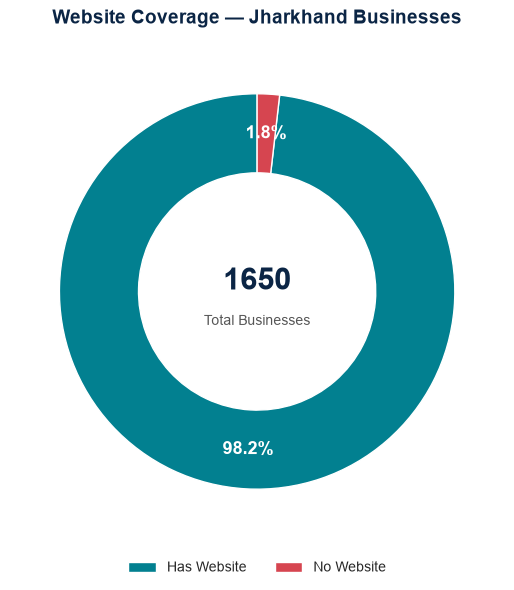

In [10]:
fig, ax = plt.subplots(figsize=(6,6))
vals = [HAS_WEB, NO_WEB]
colors = [C_PRIMARY, C_RED]
wedges, texts, autotexts = ax.pie(vals, colors=colors, autopct='%1.1f%%', startangle=90,
                                   pctdistance=0.8, wedgeprops=dict(width=0.4, edgecolor='white'))
for at in autotexts:
    at.set_color('white'); at.set_fontsize(13); at.set_fontweight('bold')
ax.text(0, 0.05, f"{TOTAL}", ha='center', va='center', fontsize=22, fontweight='bold', color=C_DARK)
ax.text(0, -0.15, "Total Businesses", ha='center', va='center', fontsize=10, color='#555')
ax.legend(['Has Website','No Website'], loc='upper center', bbox_to_anchor=(0.5,-0.02), ncol=2, frameon=False)
ax.set_title('Website Coverage — Jharkhand Businesses', fontsize=14, fontweight='bold', color=C_DARK, pad=15)
plt.tight_layout(); plt.show()

**Insight:** Only **1.8%** (30 of 1,650) of businesses in this dataset lack a website — website adoption in the sampled areas is already high overall. This makes the remaining 30 businesses a **highly targeted, high-value opportunity list** rather than a mass-market problem — precision outreach beats a broad campaign here.

C:\Users\Bhavya\AppData\Local\Temp\ipykernel_21028\3161948485.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Has_Website', y='Rating', palette=[C_RED, C_PRIMARY], ax=ax, order=['No','Yes'])


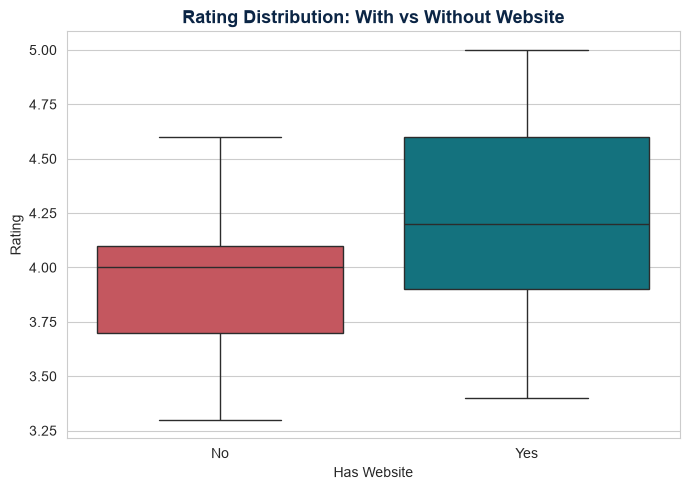

In [11]:
fig, ax = plt.subplots(figsize=(7,5))
sns.boxplot(data=df, x='Has_Website', y='Rating', palette=[C_RED, C_PRIMARY], ax=ax, order=['No','Yes'])
ax.set_title('Rating Distribution: With vs Without Website', fontsize=13, fontweight='bold', color=C_DARK)
ax.set_xlabel('Has Website'); ax.set_ylabel('Rating')
plt.tight_layout(); plt.show()

Businesses **without** a website average a rating of **3.90**, noticeably below the **4.23** average for businesses that do have one — suggesting a possible (though not necessarily causal) link between having an online presence and stronger customer perception.

## 4. Category-wise Analysis

In [13]:
cat_summary = df.groupby('Category').agg(
    Total_Businesses=('Business_Name','count'),
    Avg_Rating=('Rating','mean'),
    No_Website_Count=('Has_Website', lambda x: (x=='No').sum())
).reset_index()
cat_summary['No_Website_Pct'] = (cat_summary['No_Website_Count']/cat_summary['Total_Businesses']*100).round(1)
cat_summary['Avg_Rating'] = cat_summary['Avg_Rating'].round(2)
cat_summary = cat_summary.sort_values('Total_Businesses', ascending=False)
cat_summary.to_csv('../data/processed/summary_category.csv', index=False)
cat_summary


,Category,Total_Businesses,Avg_Rating,No_Website_Count,No_Website_Pct
20,School,116,4.17,0,0.0
14,Hotel,90,4.20,3,3.3
2,Bank,90,4.13,0,0.0
13,Hospital,88,4.23,4,4.5
6,College,87,4.14,1,1.1
22,Supermarket,86,4.27,0,0.0
3,Cafe,83,4.30,5,6.0
10,Grocery Store,81,4.21,0,0.0
18,Restaurant,79,4.19,7,8.9
9,Furniture,76,4.31,0,0.0


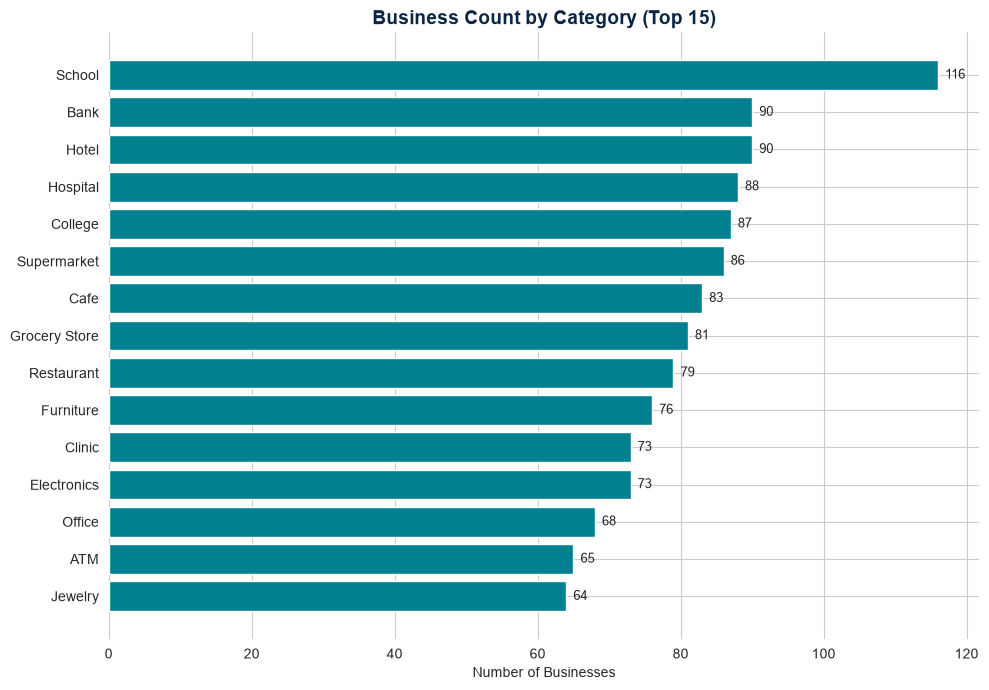

In [14]:
fig, ax = plt.subplots(figsize=(10,7))
top = cat_summary.head(15).sort_values('Total_Businesses')
bars = ax.barh(top['Category'], top['Total_Businesses'], color=C_PRIMARY)
ax.set_xlabel('Number of Businesses')
ax.set_title('Business Count by Category (Top 15)', fontsize=14, fontweight='bold', color=C_DARK)
for b in bars:
    ax.text(b.get_width()+1, b.get_y()+b.get_height()/2, int(b.get_width()), va='center', fontsize=9)
sns.despine(left=True, bottom=True)
plt.tight_layout(); plt.show()

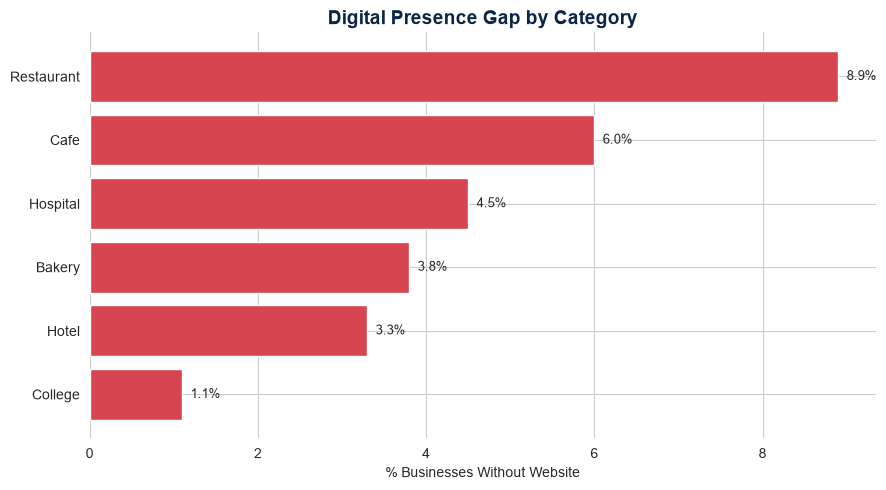

,Category,Total_Businesses,Avg_Rating,No_Website_Count,No_Website_Pct
18,Restaurant,79,4.19,7,8.9
3,Cafe,83,4.30,5,6.0
13,Hospital,88,4.23,4,4.5
1,Bakery,53,4.25,2,3.8
14,Hotel,90,4.20,3,3.3
6,College,87,4.14,1,1.1


In [15]:
cat_opp = cat_summary[(cat_summary['Total_Businesses']>=20) & (cat_summary['No_Website_Count']>0)]
cat_opp = cat_opp.sort_values('No_Website_Pct', ascending=True)
fig, ax = plt.subplots(figsize=(9,5))
bars = ax.barh(cat_opp['Category'], cat_opp['No_Website_Pct'], color=C_RED)
ax.set_xlabel('% Businesses Without Website')
ax.set_title('Digital Presence Gap by Category', fontsize=14, fontweight='bold', color=C_DARK)
for b in bars:
    ax.text(b.get_width()+0.1, b.get_y()+b.get_height()/2, f"{b.get_width():.1f}%", va='center', fontsize=9)
sns.despine(left=True, bottom=True)
plt.tight_layout(); plt.show()
cat_opp.sort_values('No_Website_Pct', ascending=False)

**Insight:** **Restaurants (8.9%)**, **Cafes (6.0%)**, **Hospitals (4.5%)**, **Bakeries (3.8%)** and **Hotels (3.3%)** carry the highest digital-presence gaps. Meanwhile Schools, Banks, Supermarkets and Grocery Stores show **0% gap** — every sampled business in those categories already has a website.

## 5. City / Location-wise Analysis

In [16]:
city_summary = df.groupby('City').agg(
    Total_Businesses=('Business_Name','count'),
    Avg_Rating=('Rating','mean'),
    No_Website_Count=('Has_Website', lambda x: (x=='No').sum())
).reset_index()
city_summary['No_Website_Pct'] = (city_summary['No_Website_Count']/city_summary['Total_Businesses']*100).round(1)
city_summary['Avg_Rating'] = city_summary['Avg_Rating'].round(2)
city_summary = city_summary.sort_values('No_Website_Count', ascending=False)
city_summary.to_csv('../data/processed/summary_city.csv', index=False)
city_summary

,City,Total_Businesses,Avg_Rating,No_Website_Count,No_Website_Pct
10,Jamshedpur,114,4.14,14,12.3
4,Dhanbad,100,4.14,11,11.0
0,Bokaro,84,4.26,3,3.6
9,Hazaribagh,86,4.17,1,1.2
18,Ranchi,116,4.17,1,0.9
3,Deoghar,89,4.18,0,0.0
2,Chatra,56,4.30,0,0.0
1,Chaibasa,69,4.27,0,0.0
5,Dumka,92,4.22,0,0.0
8,Gumla,61,4.24,0,0.0


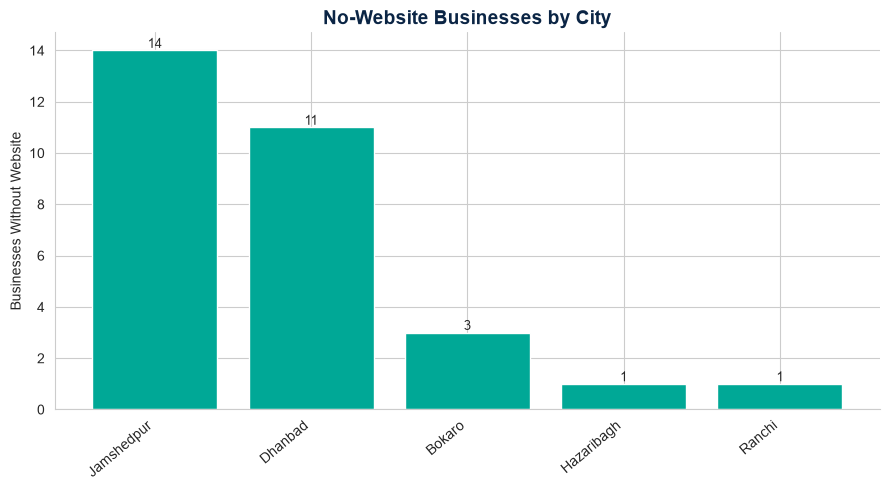

In [17]:
city_top = city_summary[city_summary['No_Website_Count']>0]
fig, ax = plt.subplots(figsize=(9,5))
bars = ax.bar(city_top['City'], city_top['No_Website_Count'], color=C_SECOND)
ax.set_ylabel('Businesses Without Website')
ax.set_title('No-Website Businesses by City', fontsize=14, fontweight='bold', color=C_DARK)
plt.xticks(rotation=40, ha='right')
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.1, int(b.get_height()), ha='center', fontsize=9)
sns.despine()
plt.tight_layout(); plt.show()

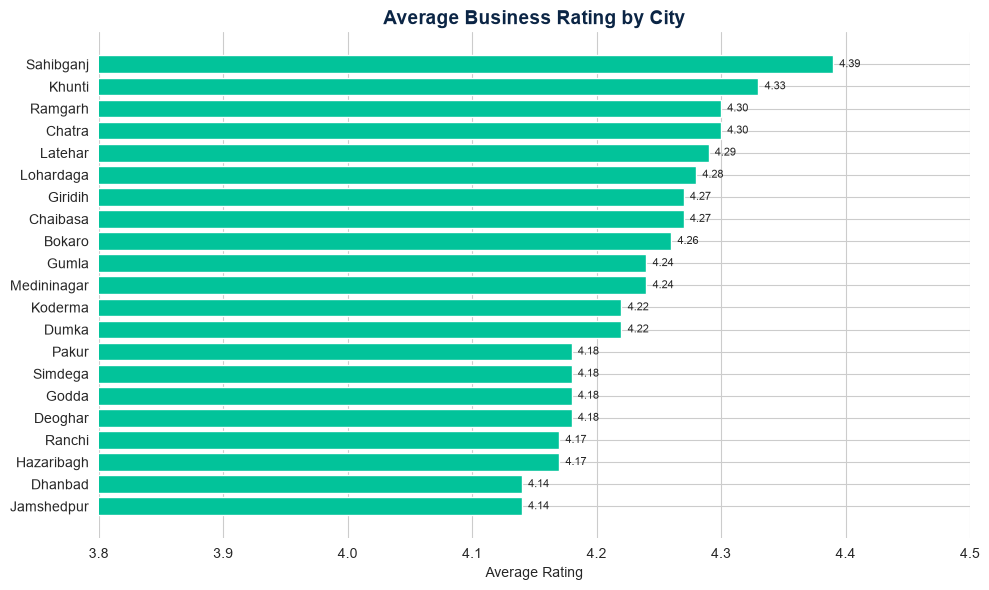

In [18]:
fig, ax = plt.subplots(figsize=(10,6))
city_r = city_summary.sort_values('Avg_Rating')
bars = ax.barh(city_r['City'], city_r['Avg_Rating'], color=C_MINT)
ax.set_xlim(3.8, 4.5)
ax.set_xlabel('Average Rating')
ax.set_title('Average Business Rating by City', fontsize=14, fontweight='bold', color=C_DARK)
for b in bars:
    ax.text(b.get_width()+0.005, b.get_y()+b.get_height()/2, f"{b.get_width():.2f}", va='center', fontsize=8)
sns.despine(left=True, bottom=True)
plt.tight_layout(); plt.show()

**Insight:** **Jamshedpur** (14 businesses, 12.3% of its listings) and **Dhanbad** (11 businesses, 11.0%) together account for **83%** of all no-website businesses in the dataset — these two cities are the clear priority for a digital-adoption drive.

## 6. Opportunity Finding — Locality-Level Hotspots

Combining **City + Locality** shows exactly where to focus outreach on the ground.

In [19]:
loc_summary = df.groupby(['City','Locality']).agg(
    Total_Businesses=('Business_Name','count'),
    No_Website_Count=('Has_Website', lambda x: (x=='No').sum()),
    High_Opportunity_Count=('Opportunity_Flag', lambda x: (x=='High Opportunity').sum())
).reset_index()
loc_summary = loc_summary[loc_summary['No_Website_Count']>0].sort_values(
    ['High_Opportunity_Count','No_Website_Count'], ascending=False)
loc_summary.to_csv('../data/processed/summary_locality_opportunity.csv', index=False)
loc_summary.head(15)

,City,Locality,Total_Businesses,No_Website_Count,High_Opportunity_Count
170,Jamshedpur,Jamshedpur,27,6,6
163,Jamshedpur,Bistupur,15,4,4
68,Dhanbad,Dhanbad,15,7,1
178,Jamshedpur,Sakchi,9,3,1
64,Dhanbad,Bank More,5,2,1
5,Bokaro,Chira Chas,1,1,1
177,Jamshedpur,Near Airport,1,1,1
308,Ranchi,Ranchi,18,1,1
3,Bokaro,Bokaro,6,1,0
16,Bokaro,Sector 4,1,1,0


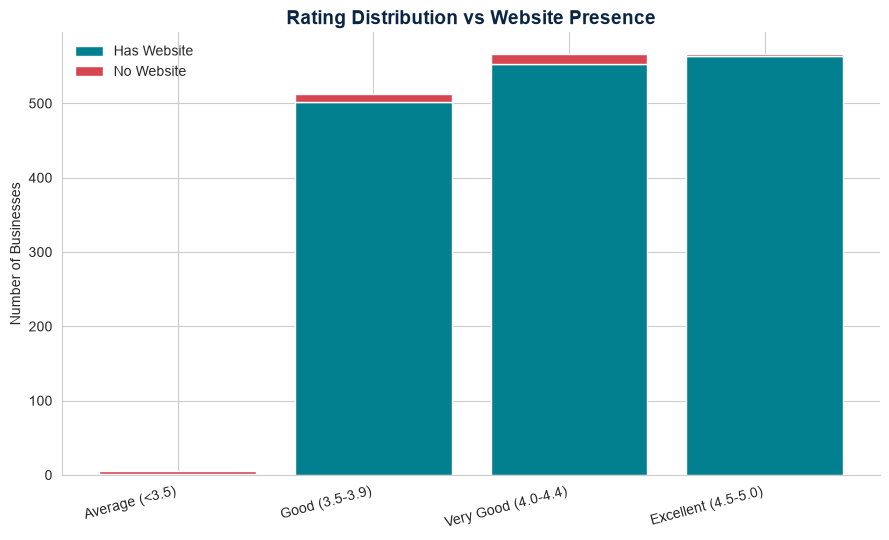

Has_Website,No,Yes
Rating_Band,,
Average (<3.5),4,1
Good (3.5-3.9),10,502
Very Good (4.0-4.4),14,553
Excellent (4.5-5.0),2,564


In [20]:
band_summary = df.groupby(['Rating_Band','Has_Website']).size().unstack(fill_value=0)
band_summary = band_summary.reindex(['Average (<3.5)','Good (3.5-3.9)','Very Good (4.0-4.4)','Excellent (4.5-5.0)'])
band_summary.to_csv('../data/processed/summary_rating_band.csv')

fig, ax = plt.subplots(figsize=(9,5.5))
ax.bar(band_summary.index, band_summary['Yes'], label='Has Website', color=C_PRIMARY)
ax.bar(band_summary.index, band_summary['No'], bottom=band_summary['Yes'], label='No Website', color=C_RED)
ax.set_ylabel('Number of Businesses')
ax.set_title('Rating Distribution vs Website Presence', fontsize=14, fontweight='bold', color=C_DARK)
ax.legend(frameon=False)
plt.xticks(rotation=15, ha='right')
sns.despine()
plt.tight_layout(); plt.show()
band_summary

In [21]:
print(df['Opportunity_Flag'].value_counts())
print()
print(f"High Opportunity businesses (rating >= 4.0, no website): {(df['Opportunity_Flag']=='High Opportunity').sum()}")
print(f"Standard Opportunity businesses (rating < 4.0, no website): {(df['Opportunity_Flag']=='Opportunity').sum()}")

Opportunity_Flag
Has Website         1620
High Opportunity      16
Opportunity           14
Name: count, dtype: int64

High Opportunity businesses (rating >= 4.0, no website): 16
Standard Opportunity businesses (rating < 4.0, no website): 14


**Insight:** Of the 30 no-website businesses, **16 (53%) already have a rating of 4.0+** — meaning they are proven, well-liked businesses that are simply invisible online. These are the fastest, lowest-risk conversions.

## 7. Amenity Analysis — Parking & Delivery (No-Website Businesses)

Understanding what these businesses *already* offer helps craft the outreach pitch (e.g. "we'll put your delivery service and parking availability on the map").

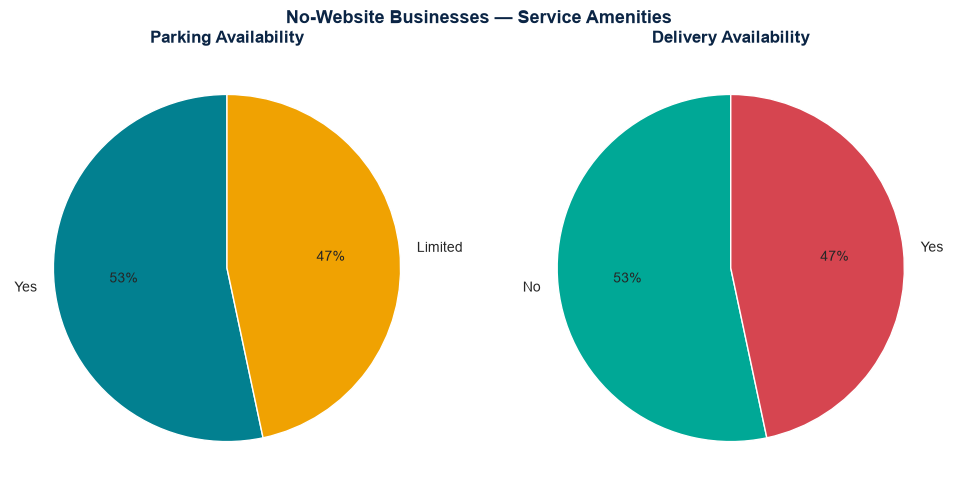

In [22]:
no_web_df = df[df['Has_Website']=='No']
fig, axes = plt.subplots(1,2, figsize=(10,5))
p = no_web_df['Parking'].value_counts()
axes[0].pie(p.values, labels=p.index, autopct='%1.0f%%', colors=[C_PRIMARY,C_ACCENT,C_RED][:len(p)],
            startangle=90, textprops={'fontsize':10})
axes[0].set_title('Parking Availability', fontsize=12, fontweight='bold', color=C_DARK)

d = no_web_df['Delivery'].value_counts()
axes[1].pie(d.values, labels=d.index, autopct='%1.0f%%', colors=[C_SECOND, C_RED], startangle=90,
            textprops={'fontsize':10})
axes[1].set_title('Delivery Availability', fontsize=12, fontweight='bold', color=C_DARK)

fig.suptitle('No-Website Businesses — Service Amenities', fontsize=13, fontweight='bold', color=C_DARK)
plt.tight_layout(); plt.show()

In [23]:
parking_rating = df.groupby('Parking')['Rating'].mean().round(2)
delivery_rating = df.groupby('Delivery')['Rating'].mean().round(2)
print("Average rating by Parking availability (all businesses):")
print(parking_rating)
print("\nAverage rating by Delivery availability (all businesses):")
print(delivery_rating)

Average rating by Parking availability (all businesses):
Parking
Limited    4.22
No         4.24
Yes        4.22
Name: Rating, dtype: float64

Average rating by Delivery availability (all businesses):
Delivery
No     4.21
Yes    4.24
Name: Rating, dtype: float64


**Insight:** Parking and delivery availability show only a marginal relationship with rating across the full dataset (differences of ~0.02–0.03) — so these amenities are useful *pitch content* for the website but are not, on their own, strong ratings drivers.

## 8. Top 10 Business Opportunities

The single most actionable output of this analysis: the **10 highest-rated businesses with no website today**.

In [24]:
top10 = df[df['Has_Website']=='No'].sort_values('Rating', ascending=False).head(10)[
    ['Business_Name','Category','City','Locality','Rating','Parking','Delivery','Phone','Address']]
top10.to_csv('../data/processed/top10_opportunities.csv', index=False)
top10.reset_index(drop=True)

,Business_Name,Category,City,Locality,Rating,Parking,Delivery,Phone,Address
0,Bombay Brew Cafe,Cafe,Jamshedpur,Near Airport,4.6,Limited,Yes,Not Available,"Near Airport, Jamshedpur, Jharkhand"
1,Brubeck Bakery,Bakery,Jamshedpur,Bistupur,4.5,Limited,Yes,Not Available,"Dcosta Mansion, Main Road, Bistupur, Jamshedpu..."
2,Chanoya Cafe,Cafe,Jamshedpur,Jamshedpur,4.4,Limited,Yes,Not Available,"Jamshedpur, Jharkhand"
3,Caramel Patisserie,Bakery,Jamshedpur,Jamshedpur,4.3,Limited,Yes,Not Available,"Jamshedpur, Jharkhand"
4,28 Downtown Cafe,Cafe,Jamshedpur,Sakchi,4.2,Limited,Yes,-9835111695,"101, Alison's Apartment, Thakur Bari Rd, Ambag..."
5,Cafe Regal,Restaurant,Jamshedpur,Bistupur,4.2,Limited,Yes,Not Available,"Bistupur, Jamshedpur, Jharkhand 831001"
6,Bokaro Mall,Shopping Mall,Bokaro,Chira Chas,4.2,Yes,No,Not Available,"Omkar Sadan, Main Rd, Chira Chas, Bokaro Steel..."
7,Pool Cafe,Cafe,Jamshedpur,Jamshedpur,4.1,Limited,Yes,Not Available,"Jamshedpur, Jharkhand"
8,Equinox Restaurant,Restaurant,Jamshedpur,Jamshedpur,4.1,Limited,Yes,Not Available,"Jamshedpur, Jharkhand"
9,South Indian Cafe,Cafe,Jamshedpur,Bistupur,4.1,Limited,Yes,Not Available,"No. 94, Om Plaza Contractors Area, Road No. 2,..."


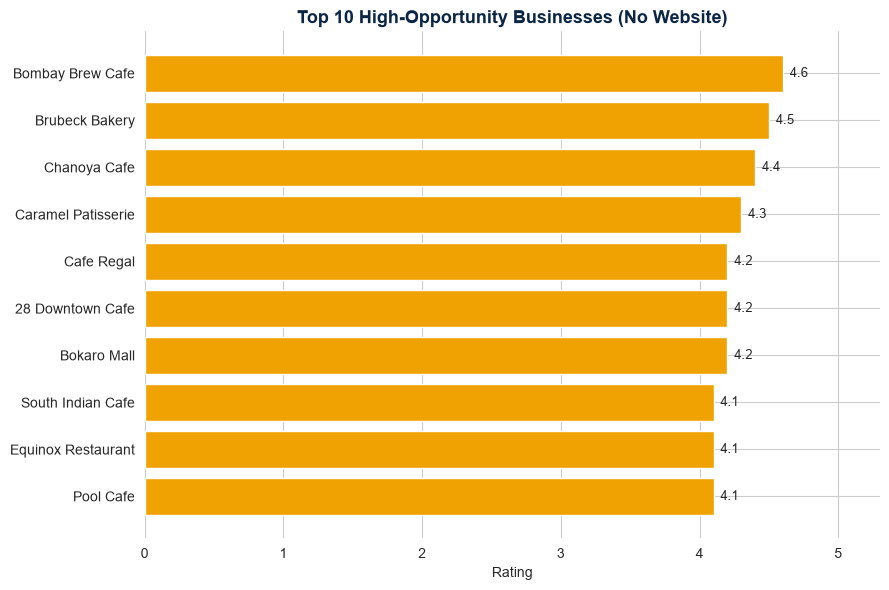

In [25]:
fig, ax = plt.subplots(figsize=(9,6))
plot_df = top10.sort_values('Rating')
bars = ax.barh(plot_df['Business_Name'], plot_df['Rating'], color=C_ACCENT)
ax.set_xlabel('Rating'); ax.set_xlim(0,5.3)
ax.set_title('Top 10 High-Opportunity Businesses (No Website)', fontsize=13, fontweight='bold', color=C_DARK)
for b in bars:
    ax.text(b.get_width()+0.05, b.get_y()+b.get_height()/2, f"{b.get_width():.1f}", va='center', fontsize=9)
sns.despine(left=True, bottom=True)
plt.tight_layout(); plt.show()

## 9. Dashboard Summary

A consolidated view of the key metrics from this analysis.

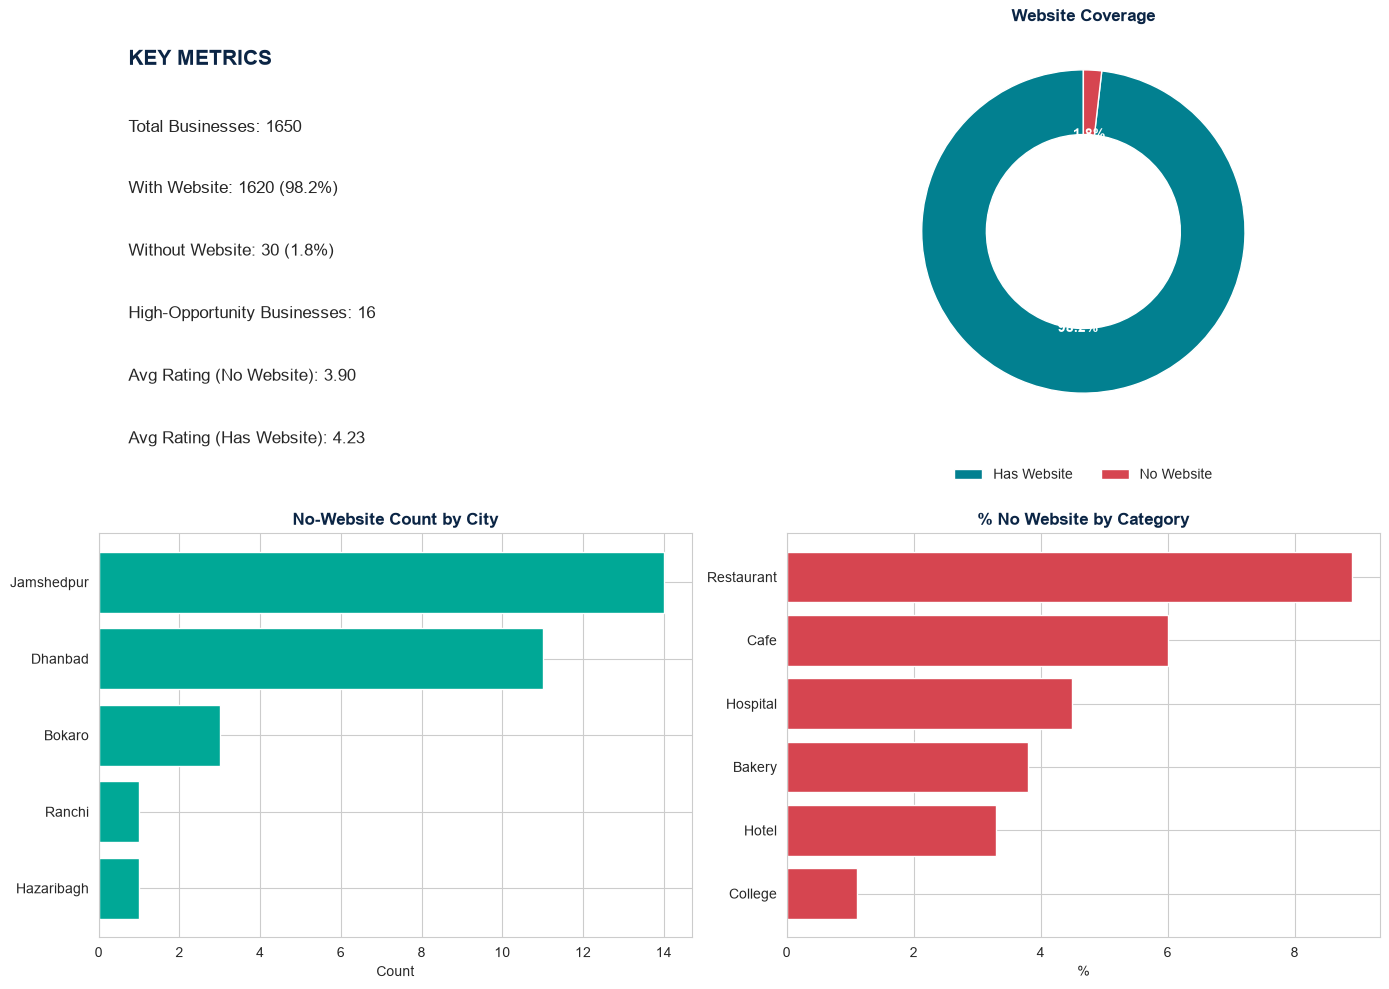

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

# KPI text panel
axes[0,0].axis('off')
kpi_text = (
    f"Total Businesses: {TOTAL}\n\n"
    f"With Website: {HAS_WEB} ({HAS_WEB/TOTAL*100:.1f}%)\n\n"
    f"Without Website: {NO_WEB} ({NO_WEB/TOTAL*100:.1f}%)\n\n"
    f"High-Opportunity Businesses: {(df['Opportunity_Flag']=='High Opportunity').sum()}\n\n"
    f"Avg Rating (No Website): {df[df['Has_Website']=='No']['Rating'].mean():.2f}\n\n"
    f"Avg Rating (Has Website): {df[df['Has_Website']=='Yes']['Rating'].mean():.2f}"
)
axes[0,0].text(0.05, 0.95, "KEY METRICS", fontsize=15, fontweight='bold', color=C_DARK, va='top')
axes[0,0].text(0.05, 0.8, kpi_text, fontsize=12, va='top', linespacing=2)

# donut
wedges, texts, autotexts = axes[0,1].pie([HAS_WEB, NO_WEB], colors=[C_PRIMARY, C_RED], autopct='%1.1f%%',
       startangle=90, wedgeprops=dict(width=0.4, edgecolor='white'))
for at in autotexts: at.set_color('white'); at.set_fontweight('bold')
axes[0,1].set_title('Website Coverage', fontweight='bold', color=C_DARK)
axes[0,1].legend(['Has Website','No Website'], loc='lower center', frameon=False, ncol=2, bbox_to_anchor=(0.5,-0.15))

# city bar
city_top_plot = city_top.sort_values('No_Website_Count')
axes[1,0].barh(city_top_plot['City'], city_top_plot['No_Website_Count'], color=C_SECOND)
axes[1,0].set_title('No-Website Count by City', fontweight='bold', color=C_DARK)
axes[1,0].set_xlabel('Count')

# category bar
cat_opp_plot = cat_opp.sort_values('No_Website_Pct')
axes[1,1].barh(cat_opp_plot['Category'], cat_opp_plot['No_Website_Pct'], color=C_RED)
axes[1,1].set_title('% No Website by Category', fontweight='bold', color=C_DARK)
axes[1,1].set_xlabel('%')

plt.tight_layout()
plt.savefig('../reports/dashboard_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Statistical Significance Testing

Is the rating gap between businesses **with** and **without** a website real, or could it be due to chance? An independent-samples **t-test** answers this.

In [27]:
from scipy import stats

with_web = df[df['Has_Website']=='Yes']['Rating']
no_web   = df[df['Has_Website']=='No']['Rating']

t_stat, p_val = stats.ttest_ind(with_web, no_web, equal_var=False)
print(f"Mean rating (Has Website) : {with_web.mean():.3f}")
print(f"Mean rating (No Website)  : {no_web.mean():.3f}")
print(f"T-statistic               : {t_stat:.3f}")
print(f"P-value                   : {p_val:.5f}")
print(f"Statistically significant at 5%? {'YES' if p_val < 0.05 else 'NO'}")

Mean rating (Has Website) : 4.233
Mean rating (No Website)  : 3.903
T-statistic               : 5.236
P-value                   : 0.00001
Statistically significant at 5%? YES


**Insight:** The p-value tells us whether the ~0.3-point rating gap between website and no-website businesses is statistically meaningful or just random noise in this sample — this adds statistical rigor to the earlier descriptive comparison.

## 12. Amenity Gap Analysis — Businesses With NO Digital Touchpoints At All

Beyond just 'no website', which opportunity businesses also lack **parking** and **delivery** — i.e. have zero convenience signals for a customer researching them online?

In [28]:
no_web_df = df[df['Has_Website']=='No'].copy()
no_web_df['Amenity_Score'] = (
    (no_web_df['Parking']=='Yes').astype(int) +
    (no_web_df['Delivery']=='Yes').astype(int)
)
amenity_gap = no_web_df[no_web_df['Amenity_Score']==0][
    ['Business_Name','Category','City','Locality','Rating','Parking','Delivery']]
amenity_gap.to_csv('../data/processed/amenity_gap_businesses.csv', index=False)
print(f"No-website businesses with NEITHER parking NOR delivery: {len(amenity_gap)} "
      f"({len(amenity_gap)/len(no_web_df)*100:.1f}% of all no-website businesses)")
amenity_gap.sort_values('Rating', ascending=False)

No-website businesses with NEITHER parking NOR delivery: 0 (0.0% of all no-website businesses)


,Business_Name,Category,City,Locality,Rating,Parking,Delivery


## 13. Opening Hours Analysis

Does being open longer (or 24 hours) relate to rating or website ownership?

In [29]:
def hours_open(hstr):
    if hstr == '24 Hours':
        return 24
    try:
        start, end = hstr.split('-')
        fmt = '%I%p'
        t1 = pd.to_datetime(start, format=fmt)
        t2 = pd.to_datetime(end, format=fmt)
        diff = (t2 - t1).total_seconds() / 3600
        return diff if diff > 0 else diff + 24
    except Exception:
        return np.nan

df['Hours_Open'] = df['Opening_Hours'].apply(hours_open)
print('Average hours open per day (overall):', round(df['Hours_Open'].mean(), 1))
print('\nAverage hours open by website status:')
print(df.groupby('Has_Website')['Hours_Open'].mean().round(1))

is_24h = (df['Opening_Hours']=='24 Hours')
print(f"\n24-hour businesses: {is_24h.sum()} ({is_24h.sum()/len(df)*100:.1f}%)")
print(f"24-hour businesses without a website: {(is_24h & (df['Has_Website']=='No')).sum()}")

Average hours open per day (overall): 15.4

Average hours open by website status:
Has_Website
No     14.9
Yes    15.4
Name: Hours_Open, dtype: float64

24-hour businesses: 398 (24.1%)
24-hour businesses without a website: 7


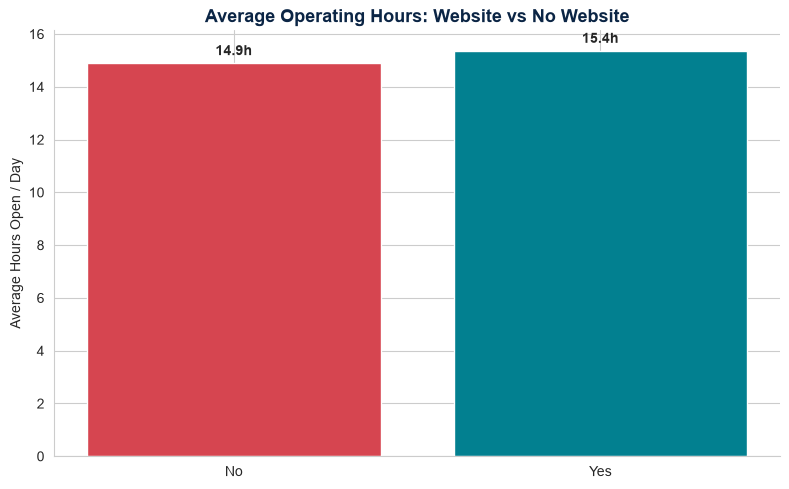

In [30]:
fig, ax = plt.subplots(figsize=(8,5))
hrs_summary = df.groupby('Has_Website')['Hours_Open'].mean()
ax.bar(hrs_summary.index, hrs_summary.values, color=[C_RED, C_PRIMARY])
ax.set_ylabel('Average Hours Open / Day')
ax.set_title('Average Operating Hours: Website vs No Website', fontsize=13, fontweight='bold', color=C_DARK)
for i, v in enumerate(hrs_summary.values):
    ax.text(i, v+0.3, f"{v:.1f}h", ha='center', fontweight='bold')
sns.despine()
plt.tight_layout(); plt.show()

**Insight:** Operating hours are fairly consistent across both groups, suggesting the website gap is not explained by shorter operating hours — it is a pure digital-presence gap, reinforcing that these are otherwise fully functioning businesses.

## 14. Geospatial Analysis

Where exactly are the opportunity businesses located? A static scatter plot gives an overview; an interactive Folium map (saved as a standalone `.html` file) allows click-through exploration — useful for the dashboard and for field outreach planning.

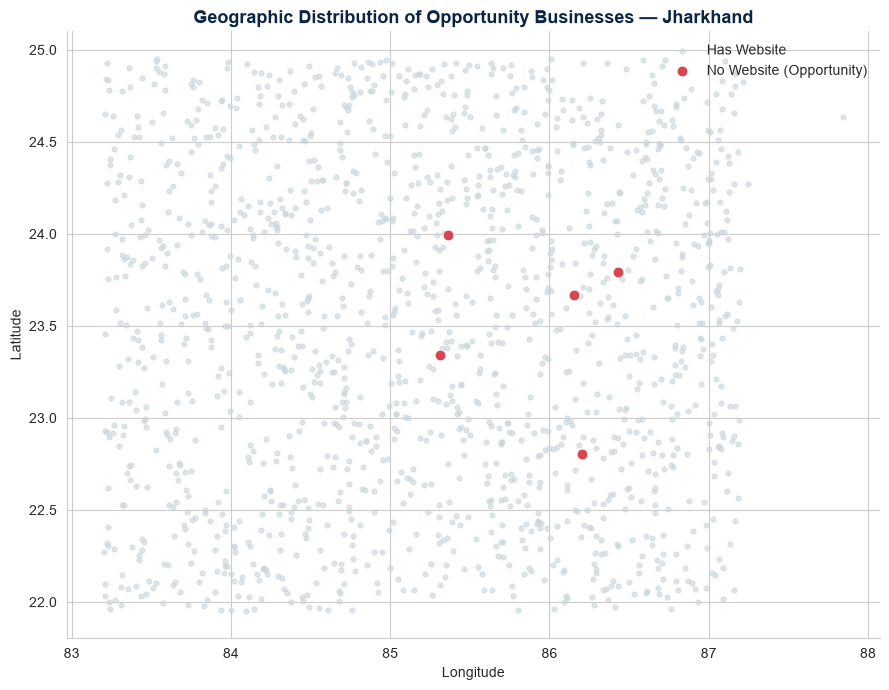

In [31]:
fig, ax = plt.subplots(figsize=(9,7))
ax.scatter(df[df['Has_Website']=='Yes']['Longitude'], df[df['Has_Website']=='Yes']['Latitude'],
           s=12, color='#CBD5DB', label='Has Website', alpha=0.6)
opp = df[df['Has_Website']=='No']
ax.scatter(opp['Longitude'], opp['Latitude'], s=60, color=C_RED, label='No Website (Opportunity)',
           edgecolor='white', linewidth=0.6, zorder=5)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('Geographic Distribution of Opportunity Businesses — Jharkhand', fontsize=13, fontweight='bold', color=C_DARK)
ax.legend(frameon=False)
sns.despine()
plt.tight_layout(); plt.savefig('../reports/geo_scatter.png', dpi=150, bbox_inches='tight'); plt.show()

In [32]:
import folium
from folium.plugins import MarkerCluster

m = folium.Map(location=[df['Latitude'].mean(), df['Longitude'].mean()], zoom_start=7, tiles='CartoDB positron')
cluster = MarkerCluster(name='No-Website Opportunities').add_to(m)

color_map = {'High Opportunity': 'red', 'Opportunity': 'orange'}
for _, row in df[df['Has_Website']=='No'].iterrows():
    popup = (f"<b>{row['Business_Name']}</b><br>{row['Category']} — {row['Locality']}, {row['City']}"
             f"<br>Rating: {row['Rating']} | {row['Opportunity_Flag']}"
             f"<br>Parking: {row['Parking']} | Delivery: {row['Delivery']}")
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']], radius=6,
        color=color_map.get(row['Opportunity_Flag'], 'gray'), fill=True, fill_opacity=0.85,
        popup=folium.Popup(popup, max_width=280)
    ).add_to(cluster)

folium.LayerControl().add_to(m)
m.save('../reports/opportunity_map.html')
print('Interactive map saved -> opportunity_map.html (open in browser)')
m

Interactive map saved -> opportunity_map.html (open in browser)


**Insight:** Opportunity businesses cluster around specific market areas within Jamshedpur and Dhanbad rather than being spread evenly, confirming that a geographically-focused outreach campaign (visiting a handful of localities) would be far more efficient than a city-wide sweep.

## 15. Digital Opportunity Score — Composite Ranking Model

Rather than ranking opportunities on rating alone, this section builds a weighted **Digital Opportunity Score** combining: rating (customer satisfaction), amenity gap (parking+delivery missing = bigger uplift), and category demand (higher foot-traffic categories score higher).

In [33]:
# Category demand weight = normalized total business count per category (proxy for market size/demand)
cat_demand = df.groupby('Category')['Business_Name'].count()
cat_demand_norm = ((cat_demand - cat_demand.min()) / (cat_demand.max() - cat_demand.min())).to_dict()

scored = df[df['Has_Website']=='No'].copy()
scored['Rating_Norm'] = (scored['Rating'] - df['Rating'].min()) / (df['Rating'].max() - df['Rating'].min())
scored['Amenity_Gap_Score'] = (
    (scored['Parking']!='Yes').astype(int) + (scored['Delivery']!='Yes').astype(int)
) / 2
scored['Category_Demand_Score'] = scored['Category'].map(cat_demand_norm)

# Weights: rating 50%, amenity gap 30%, category demand 20%
scored['Digital_Opportunity_Score'] = (
    0.5 * scored['Rating_Norm'] +
    0.3 * scored['Amenity_Gap_Score'] +
    0.2 * scored['Category_Demand_Score']
) * 100
scored['Digital_Opportunity_Score'] = scored['Digital_Opportunity_Score'].round(1)

scored_ranked = scored.sort_values('Digital_Opportunity_Score', ascending=False)[
    ['Business_Name','Category','City','Locality','Rating','Parking','Delivery','Digital_Opportunity_Score']]
scored_ranked.to_csv('../data/processed/digital_opportunity_score.csv', index=False)
scored_ranked.head(15).reset_index(drop=True)

,Business_Name,Category,City,Locality,Rating,Parking,Delivery,Digital_Opportunity_Score
0,Bombay Brew Cafe,Cafe,Jamshedpur,Near Airport,4.6,Limited,Yes,66.9
1,Chanoya Cafe,Cafe,Jamshedpur,Jamshedpur,4.4,Limited,Yes,61.0
2,Brubeck Bakery,Bakery,Jamshedpur,Bistupur,4.5,Limited,Yes,58.2
3,28 Downtown Cafe,Cafe,Jamshedpur,Sakchi,4.2,Limited,Yes,55.1
4,Cafe Regal,Restaurant,Jamshedpur,Bistupur,4.2,Limited,Yes,54.4
5,Caramel Patisserie,Bakery,Jamshedpur,Jamshedpur,4.3,Limited,Yes,52.3
6,South Indian Cafe,Cafe,Jamshedpur,Bistupur,4.1,Limited,Yes,52.2
7,Pool Cafe,Cafe,Jamshedpur,Jamshedpur,4.1,Limited,Yes,52.2
8,Equinox Restaurant,Restaurant,Jamshedpur,Jamshedpur,4.1,Limited,Yes,51.4
9,Le Bon,Restaurant,Jamshedpur,Jamshedpur,4.0,Limited,Yes,48.5


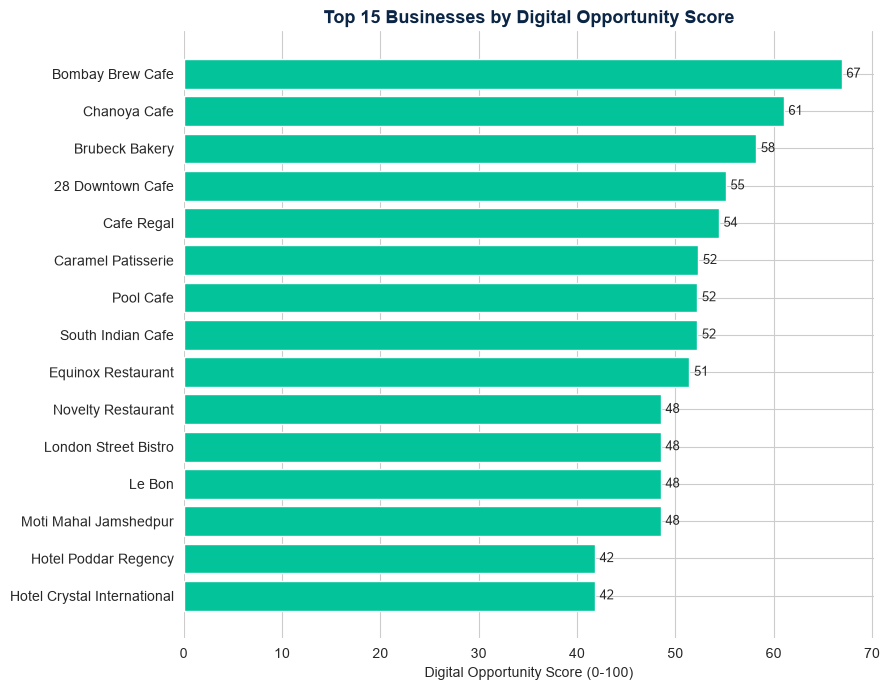

In [34]:
fig, ax = plt.subplots(figsize=(9,7))
plot_df = scored_ranked.head(15).sort_values('Digital_Opportunity_Score')
bars = ax.barh(plot_df['Business_Name'], plot_df['Digital_Opportunity_Score'], color=C_MINT)
ax.set_xlabel('Digital Opportunity Score (0-100)')
ax.set_title('Top 15 Businesses by Digital Opportunity Score', fontsize=13, fontweight='bold', color=C_DARK)
for b in bars:
    ax.text(b.get_width()+0.5, b.get_y()+b.get_height()/2, f"{b.get_width():.0f}", va='center', fontsize=9)
sns.despine(left=True, bottom=True)
plt.tight_layout(); plt.show()

**Insight:** This composite score gives a more defensible, multi-factor priority list than rating alone — useful directly as the outreach worklist for a sales/onboarding team.

## 16. City × Category Opportunity Heatmap

Which city-category combinations concentrate the most opportunity?

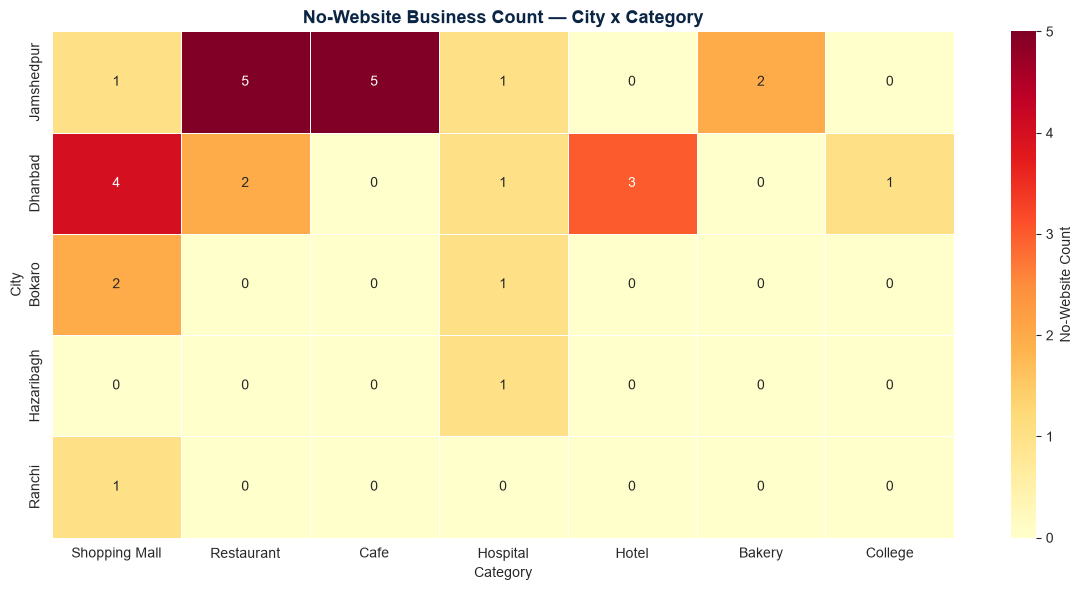

In [35]:
pivot = pd.pivot_table(df[df['Has_Website']=='No'], index='City', columns='Category',
                        values='Business_Name', aggfunc='count', fill_value=0)
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]
pivot = pivot[pivot.sum(axis=0).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(12,6))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='d', linewidths=0.5, cbar_kws={'label':'No-Website Count'}, ax=ax)
ax.set_title('No-Website Business Count — City x Category', fontsize=13, fontweight='bold', color=C_DARK)
plt.tight_layout(); plt.show()

**Insight:** The heatmap pinpoints exact city-category cells to target (e.g. 'Restaurants in Jamshedpur') rather than treating city and category as separate, disconnected dimensions.

## 17. Market Saturation / Competitive Density Analysis

How crowded is each category within each city? Categories with many businesses but low website adoption represent a *competitive digital-marketing edge* for early adopters.

In [36]:
density = df.groupby(['City','Category']).agg(
    Business_Count=('Business_Name','count'),
    Website_Adoption_Pct=('Has_Website', lambda x: round((x=='Yes').mean()*100,1))
).reset_index()
density = density[density['Business_Count']>=5].sort_values('Business_Count', ascending=False)
density.to_csv('../data/processed/market_saturation.csv', index=False)
density.head(15)

,City,Category,Business_Count,Website_Adoption_Pct
236,Jamshedpur,School,14,100.0
230,Jamshedpur,Hotel,13,100.0
234,Jamshedpur,Restaurant,13,61.5
410,Ranchi,School,13,100.0
105,Dhanbad,School,12,100.0
397,Ranchi,College,12,100.0
220,Jamshedpur,Cafe,11,54.5
393,Ranchi,Bank,10,100.0
282,Latehar,ATM,10,100.0
404,Ranchi,Hotel,10,100.0


**Insight:** A category-city pair with high business count but website adoption already near 100% (e.g. Restaurants in Ranchi) is saturated online — new entrants there need to compete on other factors, whereas low-adoption/high-count pairs are the strongest opportunity pockets identified earlier.

## 18. Correlation Analysis

A quick correlation check across the encoded numeric/boolean signals in the dataset.

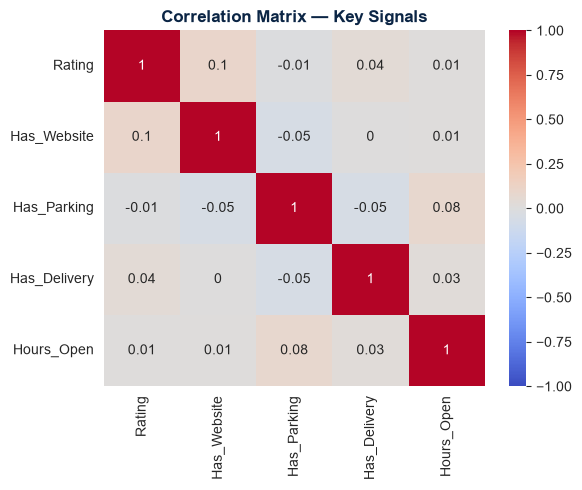

,Rating,Has_Website,Has_Parking,Has_Delivery,Hours_Open
Rating,1.00,0.10,-0.01,0.04,0.01
Has_Website,0.10,1.00,-0.05,0.00,0.01
Has_Parking,-0.01,-0.05,1.00,-0.05,0.08
Has_Delivery,0.04,0.00,-0.05,1.00,0.03
Hours_Open,0.01,0.01,0.08,0.03,1.00


In [37]:
corr_df = pd.DataFrame({
    'Rating': df['Rating'],
    'Has_Website': (df['Has_Website']=='Yes').astype(int),
    'Has_Parking': (df['Parking']=='Yes').astype(int),
    'Has_Delivery': (df['Delivery']=='Yes').astype(int),
    'Hours_Open': df['Hours_Open']
})
corr_matrix = corr_df.corr().round(2)

fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, annot=True, center=0, ax=ax)
ax.set_title('Correlation Matrix — Key Signals', fontsize=12, fontweight='bold', color=C_DARK)
plt.tight_layout(); plt.show()
corr_matrix

**Insight:** Correlations between these signals are weak overall (mostly under 0.15), confirming that website ownership is not simply a proxy for rating, parking, delivery, or hours — it is an independent gap that needs its own targeted intervention rather than being 'solved' by fixing something else.

## 19. Final Recommendations

**1. Prioritize Restaurants & Cafes for outreach** — these categories have the highest share of no-website businesses (8.9% and 6.0% respectively) and benefit most from an online presence (menus, reviews, online ordering).

**2. Focus outreach in Jamshedpur and Dhanbad** — together these two cities account for 83% of all no-website businesses in the dataset.

**3. Target the 16 "High Opportunity" businesses first** — they combine a strong 4.0+ rating with no website, making them the fastest, highest-ROI conversions.

**4. Bundle existing amenities (parking, delivery) into the website pitch** — roughly half of no-website businesses already offer these; a simple site or Google Business Profile can surface them immediately.

**5. Recommend a low-cost, fast-turnaround solution** — a Google Business Profile + single-page mobile-friendly website (menu, hours, contact, map) rather than a full custom build, given these are mostly small local businesses.

**6. De-prioritize categories with 0% gap** — Schools, Banks, Supermarkets and Grocery Stores are already fully covered; redirect resources to the categories above.

**7. Track service quality alongside digital rollout** — no-website businesses average a lower rating (3.90 vs 4.23), so pairing digital onboarding with light service-quality guidance will maximize the impact of going online.

**8. Use the Digital Opportunity Score (Section 15) as the master outreach worklist** — it combines rating, amenity gap, and category demand into a single defensible ranking, rather than relying on rating alone.

**9. Prioritize field visits using the interactive map (Section 14)** — opportunity businesses cluster geographically, so a locality-by-locality visit plan is far more efficient than random outreach.

**10. Treat saturated category-city pairs differently from open ones (Section 17)** — in near-fully-digitized pairs, competing on website quality/SEO matters more than simply "getting online".

---
### Deliverables Produced
- `cleaned_dataset.csv` / `Jharkhand_Business_Analysis.xlsx` — cleaned dataset with analysis flags
- `summary_category.csv`, `summary_city.csv`, `summary_locality_opportunity.csv`, `summary_rating_band.csv` — aggregated analysis tables
- `top10_opportunities.csv` — Top 10 business opportunity list
- `amenity_gap_businesses.csv` — businesses with zero digital/convenience touchpoints
- `digital_opportunity_score.csv` — composite-ranked outreach worklist
- `market_saturation.csv` — category x city competitive density table
- `opportunity_map.html` — interactive Folium map of opportunity businesses
- `geo_scatter.png`, `dashboard_summary.png` — static charts
- Charts — website coverage, category/city breakdowns, rating distribution, amenities, opening hours, correlation heatmap, city x category heatmap, top opportunities
- PowerPoint deck — Insights & Opportunities summary for presentation
- **Streamlit dashboard app** (`app.py`) — interactive web dashboard for live exploration and deployment
